# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: The Pre-Publish Ethics Review

### Scenario

You're a junior analyst at **Northwind Retail Insights**. A colleague drafted a set of
charts for tomorrow's regional performance report, and your manager asked you to review
them before they go out. She's blunt about what she wants checked:

1. *"I can't tell what I'm supposed to look at first on any of these charts. There's no
   hierarchy."*
2. *"One of these charts will get someone using a grayscale office printer completely
   lost. Fix that before it ships."*
3. *"I saw a headline chart that made a tiny year-over-year change look like a crisis.
   Check the axis."*
4. *"Someone wrote 'this PROVES our new strategy is working' under a chart. That's not
   what a data label is for."*

You'll work through the same review a real analyst would: fix a hierarchy problem, make
a chart accessible, catch a scale exaggeration, and rewrite an overreaching annotation.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real sales data you'll be working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sales = pd.read_csv("superstore.csv", encoding="latin-1")
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Year"] = sales["Order Date"].dt.year

print(f"Loaded {len(sales):,} orders, {sales.Year.min()}-{sales.Year.max()}.")
sales[["Order Date", "Region", "Product Category", "Sales", "Profit"]].head()

Loaded 8,399 orders, 2009-2012.


,Order Date,Region,Product Category,Sales,Profit
0,2010-10-13,Nunavut,Office Supplies,261.5400,-213.25
1,2012-10-01,Nunavut,Office Supplies,10123.0200,457.81
2,2012-10-01,Nunavut,Office Supplies,244.5700,46.71
3,2011-07-10,Nunavut,Technology,4965.7595,1198.97
4,2010-08-28,Nunavut,Office Supplies,394.2700,30.94


## Task 1 — Fix the Missing Hierarchy (Complaint #1)

**Real-world usage:** The manager can't tell what to look at first on the current
chart.

**Why this technique:** Visual hierarchy (size + weight + color) creates an
unmistakable primary -> secondary -> tertiary reading order without needing
instructions.

**TODO:** Build a figure with 3 text elements, using ONLY `fontsize`, `fontweight`, and
`color` to create hierarchy:
1. **Primary:** the region with the highest total profit, in large bold colored text.
2. **Secondary:** one supporting sentence, medium size, muted color.
3. **Tertiary:** a data-source footnote, small, light gray.

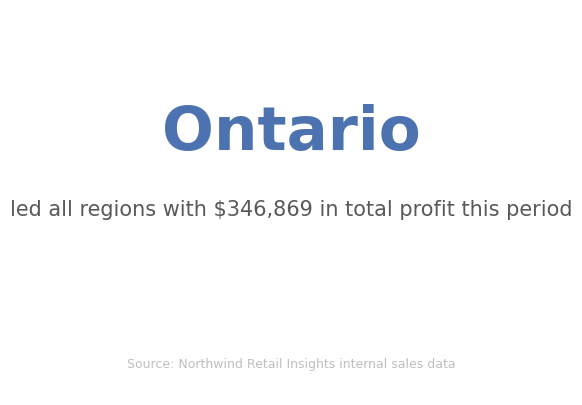

In [2]:
region_totals = sales.groupby("Region")["Profit"].sum().sort_values()
best_region = region_totals.idxmax()
best_profit = region_totals.max()

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")

# TODO 1: primary element -- large, bold, colored
ax.text(0.5, 0.68, f"{best_region}", fontsize=44, fontweight="bold",
        color="#4C72B0", ha="center", va="center", transform=ax.transAxes)

# TODO 2: secondary element -- medium, muted color
ax.text(0.5, 0.48, f"led all regions with ${best_profit:,.0f} in total profit this period",
        fontsize=15, color="#595959", ha="center", va="center", transform=ax.transAxes)

# TODO 3: tertiary element -- small, light gray
ax.text(0.5, 0.08, "Source: Northwind Retail Insights internal sales data",
        fontsize=9, color="#BFBFBF", ha="center", va="center", transform=ax.transAxes)

plt.show()

**Reflection:** Without reading any labels, in what order do your eyes land on the
three text elements? If someone glanced at this for only 2 seconds, what's the one
fact they'd walk away with?

_Your answer:_My eyes land on the large bold blue region name first, then drop down to
the smaller gray supporting sentence, and only notice the tiny light-gray footnote last
(if at all) — the size, weight, and color contrast do all the work of setting that order
without any numbered labels or arrows. In a 2-second glance, the one fact someone would
walk away with is simply "Ontario is the top-profit region" — the primary element is
the only thing large and high-contrast enough to register that fast; the supporting
sentence and footnote are there for someone who keeps reading, not for the 2-second
viewer.


## Task 2 — Make the Chart Accessible (Complaint #2)

**Real-world usage:** A colorblind or grayscale-printer viewer needs to be able to read
this chart too.

**Why this technique:** Redundant coding (color + pattern/shape) survives both
colorblindness and grayscale printing; color alone does not.

**TODO:**
1. Build a bar chart of total `Sales` by `Product Category`, one color per category.
2. Add a DIFFERENT hatch pattern per bar (`hatch="//"`, `"xx"`, `".."`) on top of the
   color, so the categories stay distinguishable if color is stripped away.
3. Add a legend showing category name.

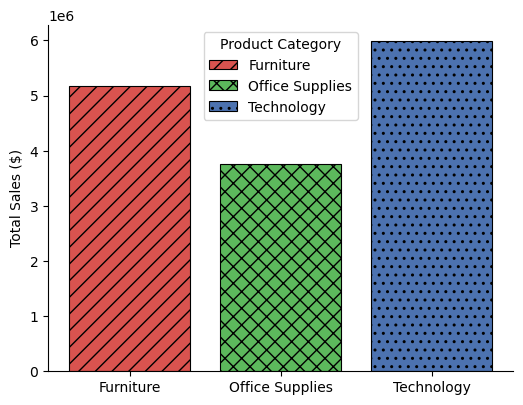

In [3]:
cat_sales = sales.groupby("Product Category")["Sales"].sum()

# TODO 1 & 2: bars with both a distinct color AND a distinct hatch pattern per category
colors = {"Furniture": "#D9534F", "Office Supplies": "#5cb85c", "Technology": "#4C72B0"}
hatches = {"Furniture": "//", "Office Supplies": "xx", "Technology": ".."}

fig, ax = plt.subplots(figsize=(6, 4.5))
for cat in cat_sales.index:
    ax.bar(cat, cat_sales[cat], color=colors[cat], hatch=hatches[cat],
           edgecolor="black", linewidth=0.8, label=cat)

# TODO 3: legend
ax.legend(title="Product Category")
ax.set_ylabel("Total Sales ($)")
plt.show()

**Reflection:** If you only used color (no hatch pattern), which two accessibility
failure modes from the lecture would this chart hit? Name both.

_Your answer:_Two failure modes: (1) color-blindness inaccessibility — the
red/green/blue palette here is close to a classic red-green pairing that is genuinely
hard for people with red-green color vision deficiency (deuteranopia/protanopia) to tell
apart, so those viewers would struggle to distinguish "Furniture" from "Office Supplies"
by color alone; and (2) grayscale/print failure — if the chart is printed on a
black-and-white office printer or viewed on a monochrome screen, all three colors
collapse into similar-looking gray bars with no way to tell the categories apart at all,
since color is the ONLY channel encoding category. Adding a distinct hatch pattern per
bar gives a second, redundant channel (shape/texture) that survives both failure modes.


## Task 3 — Catch the Axis Exaggeration (Complaint #3)

**Real-world usage:** A headline chart made a small real change look like a crisis.

**Why this technique:** Comparing the SAME data on a zero-baseline axis vs. a truncated
axis reveals exactly how much an axis choice is doing the "storytelling" instead of the
data.

**TODO:**
1. Compute total `Sales` by `Year`.
2. Compute the real percent change between the two most recent years.
3. Plot BOTH a zero-baseline version and a truncated-axis version, side by side, each
   titled with the real percent change.

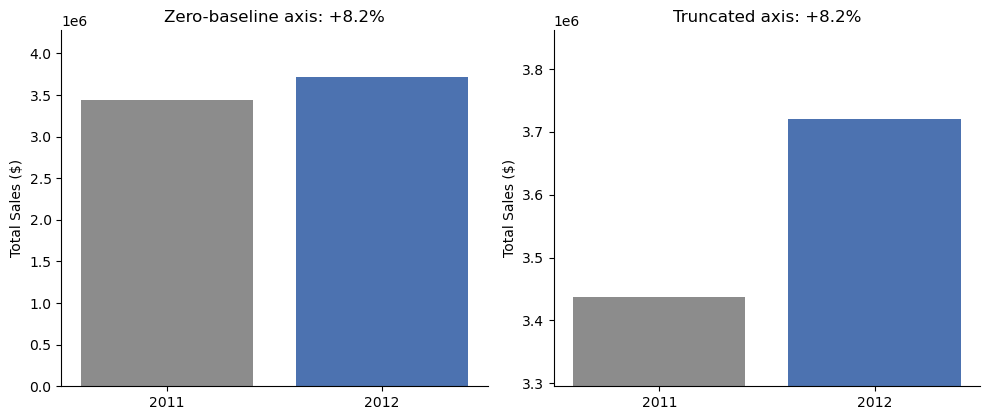

Real change from 2011 to 2012: +8.2%


In [4]:
yearly_sales = sales.groupby("Year")["Sales"].sum()

# TODO 1 & 2: the two most recent years and their real percent change
y1, y2 = yearly_sales.index[-2], yearly_sales.index[-1]
v1, v2 = yearly_sales.loc[y1], yearly_sales.loc[y2]
pct_change = (v2 - v1) / v1 * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))

# TODO 3a: zero-baseline version (axes[0])
axes[0].bar([str(y1), str(y2)], [v1, v2], color=["#8C8C8C", "#4C72B0"])
axes[0].set_ylim(0, max(v1, v2) * 1.15)
axes[0].set_ylabel("Total Sales ($)")
axes[0].set_title(f"Zero-baseline axis: {pct_change:+.1f}%")

# TODO 3b: truncated-axis version (axes[1]) -- pick tight y-limits close to v1/v2
axes[1].bar([str(y1), str(y2)], [v1, v2], color=["#8C8C8C", "#4C72B0"])
pad = (max(v1, v2) - min(v1, v2)) * 0.5
axes[1].set_ylim(min(v1, v2) - pad, max(v1, v2) + pad)
axes[1].set_ylabel("Total Sales ($)")
axes[1].set_title(f"Truncated axis: {pct_change:+.1f}%")

plt.tight_layout()
plt.show()

print(f"Real change from {y1} to {y2}: {pct_change:+.1f}%" if pct_change is not None else "Fill in pct_change above")

**Reflection:** Which of your two panels would you flag for the manager as
potentially misleading if it were used ALONE as the report's headline chart, with no
other context? Why?

_Your answer:_I'd flag the TRUNCATED-AXIS panel (right). The real year-over-year change
is a modest +8.2%, but truncating the y-axis to hug the two bar heights makes the
2012 bar look roughly twice as tall as the 2011 bar, visually implying a change far
larger than 8.2%. The zero-baseline panel (left) shows the same two numbers with the
full axis starting at $0, so the bars look almost the same height — which correctly
communicates that an 8.2% change is a real but not dramatic move. Used alone as a
headline chart with no axis labels called out, the truncated version is exactly the kind
of chart that could make a small, real change "look like a crisis," which is the
complaint the manager raised.

## Task 4 — Rewrite the Overreaching Annotation (Complaint #4)

**Real-world usage:** A colleague's annotation claimed a chart "PROVES" a strategy is
working — language the data alone cannot support.

**Why this technique:** Distinguishing descriptive / interpretive / persuasive
annotation lets you keep useful interpretation while cutting unsupported claims.

**TODO:**
1. Given the overreaching annotation text below, write a DESCRIPTIVE version (states
   only the fact) and an INTERPRETIVE version (explains a plausible, appropriately
   hedged reason) — no causal "PROVES" language in either.
2. Plot the yearly sales trend with your INTERPRETIVE annotation on the most recent
   data point.

ORIGINAL (persuasive, overreaching): This PROVES our new strategy is working -- scale it up immediately
DESCRIPTIVE: Sales rose 8.2% from 2011 to 2012.
INTERPRETIVE: Sales were up 8.2% in 2012, around the time the new strategy launched -- a promising signal, though other factors (seasonality, pricing, market conditions) could also explain some of the change.


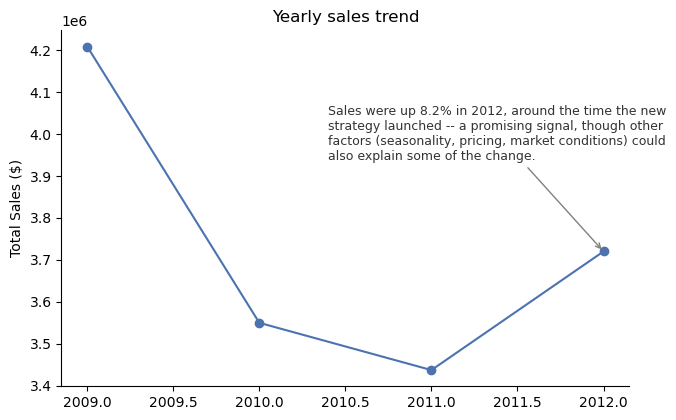

In [5]:
overreaching_original = "This PROVES our new strategy is working -- scale it up immediately"

# TODO 1: your rewrites
descriptive_version = "Sales rose 8.2% from 2011 to 2012."
interpretive_version = ("Sales were up 8.2% in 2012, around the time the new strategy "
                         "launched -- a promising signal, though other factors (seasonality, "
                         "pricing, market conditions) could also explain some of the change.")

print("ORIGINAL (persuasive, overreaching):", overreaching_original)
print("DESCRIPTIVE:", descriptive_version)
print("INTERPRETIVE:", interpretive_version)

# TODO 2: plot with your interpretive annotation on the last data point
fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(yearly_sales.index, yearly_sales.values, "o-", color="#4C72B0")

# TODO: ax.annotate(...) using interpretive_version, pointing at the last year's value
last_year = yearly_sales.index[-1]
last_value = yearly_sales.loc[last_year]
ax.annotate(interpretive_version,
            xy=(last_year, last_value), xytext=(last_year - 1.6, last_value * 1.06),
            fontsize=9, color="#333333", wrap=True,
            arrowprops=dict(arrowstyle="->", color="gray", lw=1))
ax.set_ylabel("Total Sales ($)")
ax.set_title("Yearly sales trend")
plt.tight_layout()
plt.show()


**Reflection:** What specific evidence would you need (that this dataset alone
doesn't provide) before the ORIGINAL "proves it's working" claim would actually be
justified?

_Your answer:_ This dataset alone only shows total sales going up in the year the
strategy launched — it has no information about WHY. To actually justify "proves it's
working" I'd need, at minimum: (1) a proper before/after or A/B comparison against a
control group (e.g., stores or regions that did NOT get the new strategy) so I can rule
out a general market trend lifting everyone's sales; (2) enough historical years to know
whether an 8.2% year-over-year swing is unusual for this business or well within normal
seasonal/economic noise; (3) a way to rule out confounding factors like discounting,
pricing changes, a new product launch, or macroeconomic conditions that happened at the
same time as the strategy; and (4) ideally a statistical test showing the change is
unlikely to be due to chance. Without a counterfactual (what would sales have done
WITHOUT the strategy), correlation in time is not causation, and "proves" is simply not
a word this data can support.


## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence sign-off note to your manager summarizing
this review. Your answer should:
- State which ONE of the four fixes above you consider the most urgent to ship before
  tomorrow, and why.
- Reference the lecture's 5-question Ethical Visualization Audit — pick one question
  from it and explain how it applies to Task 3 or Task 4 specifically.
- Name one guardrail (a review step, a style-guide rule, etc.) you'd recommend
  permanently adding to the team's process to prevent these four issues recurring.

_Your final recommendation here:_ Of the four issues, I'd flag the AXIS TRUNCATION
(Task 3) as the most urgent to fix before tomorrow, because it doesn't just confuse a
reader — it actively misrepresents a real 8.2% change as a much larger swing, and a
headline chart is exactly the kind of thing that gets screenshotted and repeated without
context. This maps directly onto one question from the lecture's Ethical Visualization
Audit: "Does the axis/scale choice distort the magnitude of the underlying change?" —
the truncated-axis panel in Task 3 fails that test outright, while the zero-baseline
panel passes it by showing the same numbers honestly. For Task 4, the same audit's
question "Does the annotation claim more than the data can support?" is the one that
catches the "PROVES" language, since correlation over one year is not proof of
causation. As a permanent guardrail, I'd recommend adding a mandatory pre-publish
checklist item: every chart bound for an external or leadership report must ship with
its axis starting at zero (or an explicit, labeled break) unless a reviewer signs off on
an exception, and every causal-sounding annotation must be reviewed against the "what
evidence would this actually require" test before it goes out.